<a href="https://colab.research.google.com/github/02sagoe/Crop_Damage_Classification_Challenge_Team_EggHead/blob/feature-kojo/Work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
import gdown
import zipfile
import os
import shutil
from PIL import Image
from tqdm import tqdm
import hashlib
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing import image

## Loading Images

In [2]:
# Google Drive link
file_url = "https://drive.google.com/file/d/1oUX991nPh4330ZzbXzBKKOAswhx75BtV/view?usp=sharing"

# Output filename
output = "dataset.zip"


In [3]:
# Download directly from Google Drive
gdown.download(file_url, output, quiet = False, fuzzy = True)

# Extract the zip file
extract_dir = "/content/images"
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

Downloading...
From (original): https://drive.google.com/uc?id=1oUX991nPh4330ZzbXzBKKOAswhx75BtV
From (redirected): https://drive.google.com/uc?id=1oUX991nPh4330ZzbXzBKKOAswhx75BtV&confirm=t&uuid=d57ca2be-4f72-4ee0-aab0-73e841245e66
To: /content/dataset.zip
100%|██████████| 9.26G/9.26G [01:55<00:00, 80.0MB/s]


In [4]:
print("Total files extracted:", sum(len(files) for _, _, files in os.walk("/content/images")))
print("Sample files:", os.listdir("/content/images")[:10])

Total files extracted: 34731
Sample files: ['images']


In [5]:
image_dir = f"{extract_dir}/images/"

In [6]:
image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg') or f.endswith('.png')]

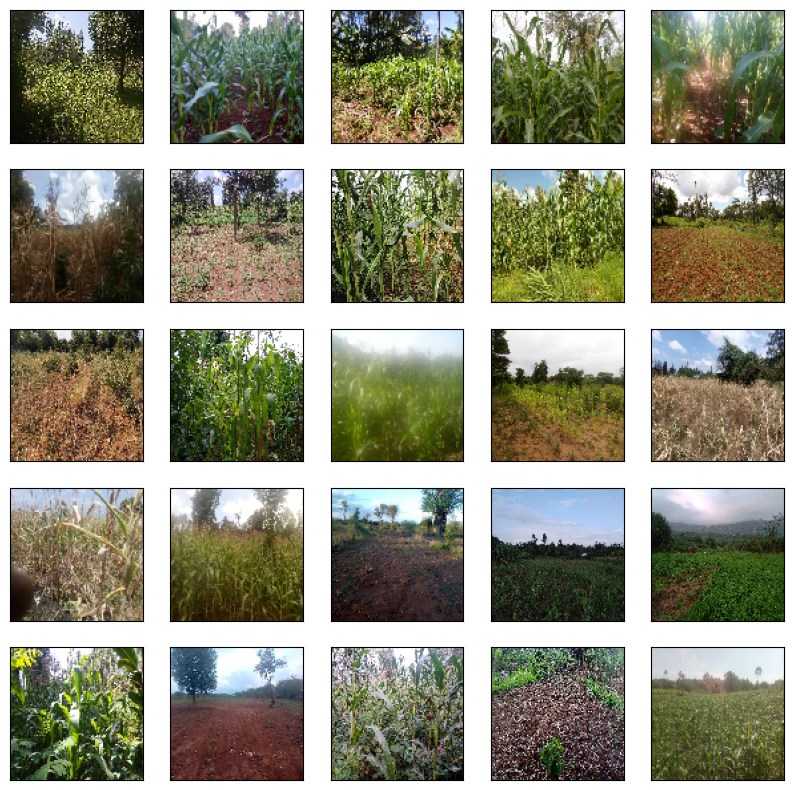

In [7]:
plt.figure(figsize = (10, 10))
# Select a subset of image files to display
sample_files = random.sample(image_files, min(25, len(image_files)))
for i, file in enumerate(sample_files):
  img_path = os.path.join(image_dir, file)
  img = image.load_img(img_path, target_size = (100, 100))  # Adjust the target size as needed
  plt.subplot(5, 5, i + 1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(img)
plt.show()

In [8]:
input_dir = "/content/images"

In [9]:
# pick first 10 image paths
image_files = []
for root, _, files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith((".jpg")):
            image_files.append(os.path.join(root, file))

In [10]:
# check sizes
for img_path in image_files:
    with Image.open(img_path) as img:
        print(f"{os.path.basename(img_path)} → {img.size}")  # (width, height)


Streaming output truncated to the last 5000 lines.
4219aebf6e2cdbd3a429332165054fda26c90ee9.jpg → (640, 480)
b048ce6d34da3c2a7f2a71e552df71f6416c0e45.jpg → (320, 240)
49210c0d56176372e05c0c398bf0419a29cb5144.jpg → (640, 480)
7c40c78c008c913010a9a1c77d1e85d9d0749033.jpg → (640, 480)
5331ab0fd9491b27e7bb6eadd7979ae2158c1990.jpg → (320, 240)
72bfd837aa3bc423c25e7e96acf0d158a9dcd73f.jpg → (3952, 1872)
5801e682d1796a8f9f376e1bdf49b5603b456bfc.jpg → (320, 240)
adf12c9da304f33d7714dcc07787768a6a55014c.jpg → (320, 240)
2ce8f99eb2926f9769022d08531faeeda06f84fb.jpg → (640, 480)
2f8fce177b223e2d5e9c93b2974b69f94245c6f9.jpg → (3264, 2448)
babbf9208c3984d29635d7ef908ae20ddd2d849c.jpg → (640, 480)
3dd085baf5b47c1e05dfe101d403e6780c906357.jpg → (320, 240)
3af5817e0f308688e0b490649ea5b7bad3f511cb.jpg → (640, 480)
e3a83aebd3d99ae02fb283cf1f5c60675a659695.jpg → (320, 240)
bc5e7976bc81891397989b2184f720e73fd95fac.jpg → (3952, 1872)
f654c5d391001d615bfc52c2382a9392e976cb91.jpg → (640, 480)
02731714f5f6e6b

KeyboardInterrupt: 

In [11]:
image_data = []
for img_path in image_files:
    try:
        with Image.open(img_path) as img:
            image_data.append({'filename': os.path.basename(img_path), 'dimensions': img.size})
    except Exception as e:
        print(f"Error processing {img_path}: {e}")

image_df = pd.DataFrame(image_data)
display(image_df.head())

,filename,dimensions
0,435fc81ba00cfb2dcce585b6e98702fbffee2997.jpg,"(640, 480)"
1,88418faead1205fb141a3d63a5b268b804784568.jpg,"(320, 240)"
2,6074cffd7f8dc9f96ac141d5633bfbd49677b732.jpg,"(640, 480)"
3,0e918c211e5b966421156f7847825186f2ea7daa.jpg,"(320, 240)"
4,6d7f357c0f0eafc6f37774666db6e80f5a3fa3a0.jpg,"(640, 480)"


In [12]:
dimension_counts = image_df.groupby('dimensions').size().reset_index(name='count')
display(dimension_counts)

,dimensions,count
0,"(102, 204)",1
1,"(117, 260)",3
2,"(120, 120)",2
3,"(120, 160)",5
4,"(121, 161)",1
5,"(121, 162)",2
6,"(122, 162)",4
7,"(150, 200)",2
8,"(153, 204)",381
9,"(160, 120)",7


## Loading Train Dataset

In [13]:
import gspread
from google.auth import default
from google.colab import auth
auth.authenticate_user()

# Autheticate and create the client
creds, _ = default()
gc = gspread.authorize(creds)

# Open the spreadsheet and select the worksheet
spreadsheet_url = 'https://docs.google.com/spreadsheets/d/1CkALzjyKZX-BeL1JpxStVTbhd_hdJJL-BlM5u7ikl2w/edit?gid=623294923#gid=623294923'
sh = gc.open_by_url(spreadsheet_url)
worksheet = sh.worksheet('Train') # Replace 'Sheet1' with the actual sheet name

# Get all values from the worksheet
data = worksheet.get_all_values()

# Convert to a pandas DataFrame
train = pd.DataFrame(data[1:], columns=data[0])

In [14]:
train.head()

,ID,damage,filename
0,ID_UBHORS,WD,d036341be8d6cd59851cb80bcc9a70cc9fbdba30.jpg
1,ID_9DSOLZ,G,9ea16180c50d0cd539897eefbfe585314e50a56b.jpg
2,ID_JHLM0G,G,b6b564844041bc68774a553eaf43d61654657dd9.jpg
3,ID_ATREIJ,DR,62262859f0cd411aaf484082ed3ef0b625bc452a.jpg
4,ID_L2GAD6,G,03b6e2a8ace7cb611eccba289f3c83d9bd497584.jpg


In [27]:
# Create a mapping dictionary for damage
damage_mapping = {
    'DR': 'Drought',
    'G': 'Good (growth)',
    'ND': 'Nutrient Deficient',
    'WD': 'Weed',
    'other': 'Disease, Pest, Wind'
}

# Add the definition column
train['definition'] = train['damage'].map(damage_mapping)

train.head(5)

,ID,damage,filename,definition
0,ID_UBHORS,WD,d036341be8d6cd59851cb80bcc9a70cc9fbdba30.jpg,Weed
1,ID_9DSOLZ,G,9ea16180c50d0cd539897eefbfe585314e50a56b.jpg,Good (growth)
2,ID_JHLM0G,G,b6b564844041bc68774a553eaf43d61654657dd9.jpg,Good (growth)
3,ID_ATREIJ,DR,62262859f0cd411aaf484082ed3ef0b625bc452a.jpg,Drought
4,ID_L2GAD6,G,03b6e2a8ace7cb611eccba289f3c83d9bd497584.jpg,Good (growth)


In [25]:
damage_counts = train.groupby('damage').size().reset_index(name='count')
display(damage_counts)

,damage,count
0,DR,4516
1,G,11623
2,ND,272
3,WD,9238
4,other,419


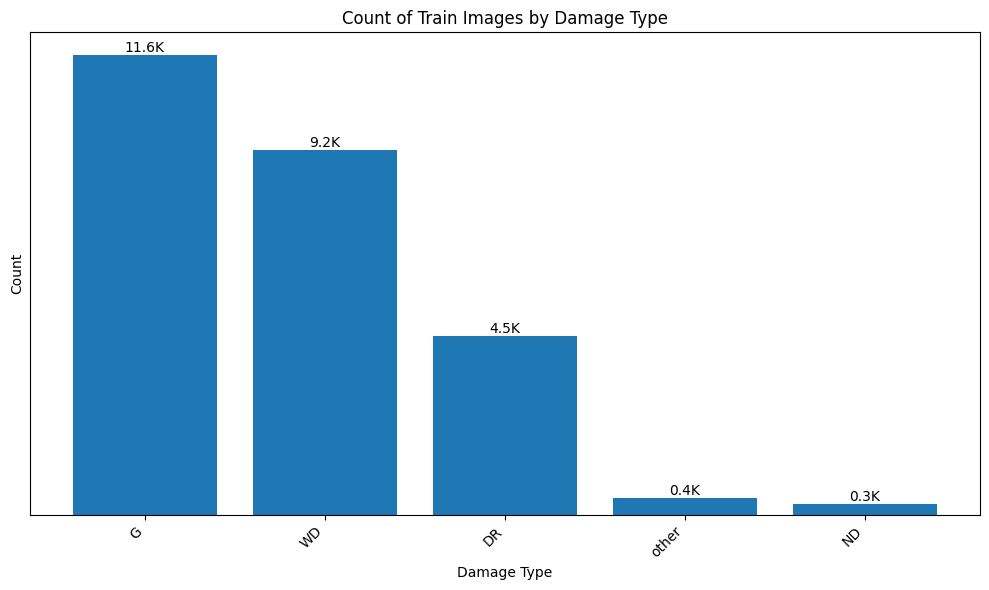

In [28]:
plt.figure(figsize=(10, 6))

# Sort the dataframe by count in descending order
damage_counts_sorted = damage_counts.sort_values(by='count', ascending=False)

bars = plt.bar(damage_counts_sorted['damage'], damage_counts_sorted['count'])
plt.xlabel('Damage Type')
plt.ylabel('Count')
plt.title('Count of Train Images by Damage Type')
plt.xticks(rotation=45, ha='right')

# Add data labels to the bars, formatted in thousands (K)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval/1000:.1f}K', va='bottom', ha='center') # va: vertical alignment, ha: horizontal alignment

plt.yticks([])
plt.tight_layout()
plt.show()

In [30]:
# First, merge the datasets on filename
merged_df = train.merge(image_df, on='filename', how='left')

# Display the merged dataframe
display(merged_df.head())

# Now analyze dimensions breakdown per damage type
# Extract width and height from dimensions tuple
merged_df['width'] = merged_df['dimensions'].apply(lambda x: x[0] if pd.notnull(x) else None)
merged_df['height'] = merged_df['dimensions'].apply(lambda x: x[1] if pd.notnull(x) else None)

# Get dimension statistics per damage type
dimension_stats = merged_df.groupby('damage').agg({
    'width': ['count', 'mean', 'std', 'min', 'max'],
    'height': ['mean', 'std', 'min', 'max']
}).round(2)

display(dimension_stats)



,ID,damage,filename,definition,dimensions
0,ID_UBHORS,WD,d036341be8d6cd59851cb80bcc9a70cc9fbdba30.jpg,Weed,"(640, 480)"
1,ID_9DSOLZ,G,9ea16180c50d0cd539897eefbfe585314e50a56b.jpg,Good (growth),"(320, 240)"
2,ID_JHLM0G,G,b6b564844041bc68774a553eaf43d61654657dd9.jpg,Good (growth),"(640, 480)"
3,ID_ATREIJ,DR,62262859f0cd411aaf484082ed3ef0b625bc452a.jpg,Drought,"(640, 480)"
4,ID_L2GAD6,G,03b6e2a8ace7cb611eccba289f3c83d9bd497584.jpg,Good (growth),"(320, 240)"


width                               height                   
        count     mean      std  min   max    mean     std  min   max
damage                                                               
DR       4516  1055.48  1172.25  117  4608  733.70  755.55  120  4160
G       11623   944.24  1080.48  120  4608  663.46  709.90  102  3456
ND        272   670.50   424.65  117  4160  499.93  292.00  144  3120
WD       9238  1153.48  1228.96  122  4608  802.95  806.56  102  3456
other     419  1127.33  1314.25  121  4608  741.20  762.90  121  3456

In [35]:
unique_dimensions = merged_df.groupby(['dimensions']).size().reset_index(name='count')
unique_dimensions = unique_dimensions.sort_values(by='count', ascending=False)
display(unique_dimensions)

,dimensions,count
22,"(640, 480)",15247
21,"(320, 240)",5983
29,"(3264, 2448)",1388
32,"(3952, 1872)",1142
39,"(4160, 3120)",590
26,"(2592, 1944)",423
6,"(153, 204)",279
36,"(4128, 1952)",111
40,"(4608, 3456)",111
25,"(2576, 1932)",111


In [37]:
dimension_pivot = pd.pivot_table(merged_df,
                                values='ID',
                                index='dimensions',
                                columns='damage',
                                aggfunc='count',
                                fill_value=0)

display(dimension_pivot)

damage,DR,G,ND,WD,other
dimensions,,,,,
"(117, 260)",1,0,1,0,0
"(120, 120)",0,1,0,0,0
"(120, 160)",3,0,0,0,0
"(121, 161)",0,0,0,0,1
"(122, 162)",2,0,0,1,0
"(150, 200)",0,0,0,1,0
"(153, 204)",105,107,4,39,24
"(160, 120)",4,0,0,0,0
"(162, 121)",0,0,0,1,2


In [36]:
# Temporarily set display options to show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

dimension_pivot = pd.pivot_table(merged_df,
                                values='ID',
                                index='damage',
                                columns='dimensions',
                                aggfunc='count',
                                fill_value=0)

display(dimension_pivot)

# Reset to default display options (optional)
pd.reset_option('display.max_columns')
pd.reset_option('display.width')

dimensions,"(117, 260)","(120, 120)","(120, 160)","(121, 161)","(122, 162)","(150, 200)","(153, 204)","(160, 120)","(162, 121)","(186, 248)","(192, 144)","(194, 194)","(195, 260)","(204, 102)","(204, 153)","(216, 216)","(240, 320)","(248, 186)","(256, 144)","(256, 192)","(260, 195)","(320, 240)","(640, 480)","(1600, 1200)","(2560, 1920)","(2576, 1932)","(2592, 1944)","(3120, 4160)","(3264, 1836)","(3264, 2448)","(3456, 3456)","(3840, 2160)","(3952, 1872)","(3968, 2976)","(4000, 1800)","(4000, 3000)","(4128, 1952)","(4128, 3096)","(4160, 1872)","(4160, 3120)","(4608, 3456)"
damage,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
DR,1,0,3,0,2,0,105,4,0,6,0,0,3,0,32,0,1,1,4,0,5,1010,2556,0,0,23,81,2,0,291,4,11,205,31,12,0,28,2,1,79,13
G,0,1,0,0,0,0,107,0,0,0,0,1,6,6,16,0,25,0,49,2,4,3412,6379,1,9,39,144,0,16,546,80,29,473,0,0,4,20,1,24,200,29
ND,1,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,5,0,0,7,250,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,2,0
WD,0,0,0,0,1,1,39,0,1,0,1,1,5,2,14,0,3,1,29,0,7,1537,5812,0,18,49,196,0,0,540,20,54,427,37,0,0,63,3,14,299,64
other,0,0,0,1,0,0,24,0,2,2,1,14,10,0,10,1,0,0,1,0,11,17,250,0,0,0,1,0,0,10,0,12,36,1,0,0,0,0,0,10,5


/tmp/ipython-input-3430429942.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x800 with 0 Axes>

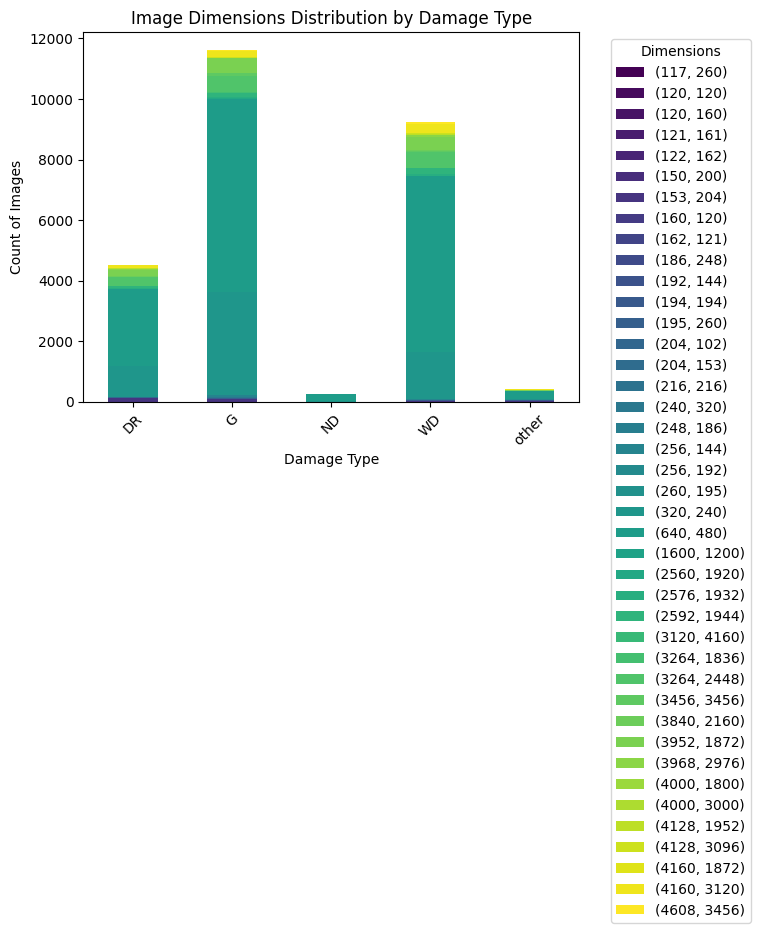

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the pivot table
dimension_pivot = pd.pivot_table(merged_df,
                                values='ID',
                                index='damage',
                                columns='dimensions',
                                aggfunc='count',
                                fill_value=0)

# Plot stacked bar chart
plt.figure(figsize=(12, 8))
dimension_pivot.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Image Dimensions Distribution by Damage Type')
plt.xlabel('Damage Type')
plt.ylabel('Count of Images')
plt.legend(title='Dimensions', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
bad_files = []

for path in tqdm(image_files, desc="Checking for corrupted images"):
    try:
        img = Image.open(path)
        img.verify()  # check if corrupted
    except Exception:
        bad_files.append(path)
        os.remove(path)

print(f"✅ Removed {len(bad_files)} corrupted images")

Checking for corrupted images: 100%|██████████| 34731/34731 [00:05<00:00, 5898.10it/s]

✅ Removed 0 corrupted images


In [23]:
seen = set()
duplicates = []

for path in tqdm(image_files, desc = "Checking for duplicates"):
    try:
        with open(path, "rb") as f:
            hash_val = hashlib.md5(f.read()).hexdigest()
        if hash_val in seen:
            os.remove(path)
            duplicates.append(path)
        else:
            seen.add(hash_val)
    except Exception as e:
        print(f"❌ Error processing {os.path.basename(path)}: {e}")

print(f"✅ Removed {len(duplicates)} duplicate images")

Checking for duplicates: 100%|██████████| 34731/34731 [01:20<00:00, 430.74it/s]

✅ Removed 0 duplicate images


### Target Size Cleaning

In [ ]:
# Target Size
size = (100, 100)

In [ ]:
for img_path in tqdm(image_files, desc = "Resizing images"):
    try:
        with Image.open(img_path).convert("RGB") as img:
            img = img.resize(size, Image.Resampling.LANCZOS)
            img.save(img_path, "JPEG")
    except Exception as e:
        print(f"❌ Error processing {os.path.basename(img_path)}: {e}")

Resizing images: 100%|██████████| 34731/34731 [23:37<00:00, 24.50it/s]


In [ ]:
image_files = []
for root, _, files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith((".jpg")):
            image_files.append(os.path.join(root, file))

In [ ]:
# check sizes
for img_path in image_files:
    with Image.open(img_path) as img:
        print(f"{os.path.basename(img_path)} → {img.size}")  # (width, height)


Streaming output truncated to the last 5000 lines.
9e46ef0fcb3648c756a70c4f4a9302248967729e.jpg → (100, 100)
8d91a7fa60a11fee52ce98f74c639fa01184f3f2.jpg → (100, 100)
c899ee3ffcacd079e01cf52cc048dd859c4d2d41.jpg → (100, 100)
01732555ffbc41356ab3faf5d2f5428860ce58a2.jpg → (100, 100)
71f502dc3cca37e1e296bb7cabdc855cab0719ca.jpg → (100, 100)
8fbc7f523307aea77efde6995d505e2abdadbf7a.jpg → (100, 100)
38f92608587f6798d79ba16a51210d7fa38cddec.jpg → (100, 100)
b3d58151f61ed9a88100bacf222811b8ed8b3f54.jpg → (100, 100)
ca333663bd8e0767b5392792ab01acb88ef36d5d.jpg → (100, 100)
4387482892568a714262353f6b9338903d83341b.jpg → (100, 100)
4bdfedb95c3e79f437820dc1c22dbb46c10c0a59.jpg → (100, 100)
9fedf2b2629abbe49dc412df9db1308a18c11bbc.jpg → (100, 100)
6f864de8b9d2a80337afefab14d8b8ee5bca3d1b.jpg → (100, 100)
15dcd5d9e99c0377de4a368c8042cb57065aceb8.jpg → (100, 100)
04a45b8b841ceae0cd72712be104e5c1214cee60.jpg → (100, 100)
4c125736f6a72d4c3f294628a38a542e2514a27b.jpg → (100, 100)
cc4ca1abeb762f0bc69ab

## Train Test Split

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
X_train, X_test = train_test_split(train, test_size = 0.2, random_state = 42)

In [40]:
len(X_train)

20854

In [41]:
len(X_test)

5214

# always use the path not the list

## Model Building

In [42]:
from fastai.vision.all import *
set_seed(42)

In [43]:
# Combine them to create a single source DataFrame with known split indices
df_combined = pd.concat([X_train, X_test], ignore_index=True)

In [44]:
# Get the indices for validation set (i.e., where test_df starts)
valid_idx = list(range(len(X_train), len(df_combined)))

In [45]:
train.head(2)

,ID,damage,filename,definition
0,ID_UBHORS,WD,d036341be8d6cd59851cb80bcc9a70cc9fbdba30.jpg,Weed
1,ID_9DSOLZ,G,9ea16180c50d0cd539897eefbfe585314e50a56b.jpg,Good (growth)


In [46]:
# Define DataBlock with IndexSplitter to respect your manual split
plant_db = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=lambda x: Path(image_dir) / x['filename'],    # image directory
    get_y=lambda x: x['damage'],                        # target variable
    splitter=IndexSplitter(valid_idx),
    batch_tfms=aug_transforms()
)

In [47]:
# Create DataLoaders from the combined df
dls = plant_db.dataloaders(df_combined, bs=32)

In [49]:
# Show a batch
dls.show_batch(max_n=9, figsize=(12,12))

RuntimeError: Error when trying to collate the data into batches with fa_collate, at least two tensors in the batch are not the same size.

Mismatch found on axis 0 of the batch and is of type `TensorImage`:
	Item at index 0 has shape: torch.Size([3, 2448, 3264])
	Item at index 1 has shape: torch.Size([3, 480, 640])

Please include a transform in `after_item` that ensures all data of type TensorImage is the same size

In [ ]:
# Create learner
learn = vision_learner(dls, resnet34, metrics=[accuracy, error_rate])

In [ ]:
# Train the model
learn.fine_tune(5)

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.138967,1.050933,0.527810,0.472190,32:36


epoch,train_loss,valid_loss,accuracy,error_rate,time


In [ ]:
# Interpret results
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()
interp.plot_top_losses(9, figsize=(15,10))

In [ ]:
# Save model
learn.export('crop_damage_classifier.pkl')

In [ ]:
# Create test DataLoader (assuming test_df is untouched during training)
test_dl = dls.test_dl(X_test)

# Get predictions
preds, _ = learn.get_preds(dl=test_dl)

# Get predicted classes
pred_classes = preds.argmax(dim=1)

# Map to class labels
pred_labels = [dls.vocab[i] for i in pred_classes]

# Add to test_df for analysis
test_df = test_df.copy()
test_df['predicted_label'] = pred_labels

# Calculate accuracy manually if you have true labels
from sklearn.metrics import accuracy_score
acc = accuracy_score(test_df['data_type'], test_df['predicted_label'])
print(f"Test Accuracy: {acc:.4f}")